# Exploring Tree Based Methods

After high performance metrics were observed in previous notebooks, it was discussed that models are likely overfitting. With 268 rows and roughly 400 features, if overfitting is being observed on linear regression models it was suspected that tree based models would do even worse. As such, this notebook follows on from experiments which have already explored regression methods on the multi-city dataset, with the aim of exploring how tree based methods perform on a dataset with more rows. Regression models will still be used for direct comparison within the notebook. 

The notebook has two potentiall outcomes:
1) To produce a high performance model which may be considered over a linear regression model
2) To gain insight on feature importance

Note also that a lot of the code for data preparation and EDA are copied from the previous regression_across_snapshots notebook. The code is reused with analysis repeated since there the dataset only covered Bristol but here the extended dataset is used, covering multiple cities.

In [289]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from itertools import product

from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, r2_score

from xgboost import XGBRegressor

from scipy.stats import spearmanr

import shap



RANDOM_STATE = 19


## Prepare Datasets

### Perform Loads and Joins

In [290]:
from pathlib import Path
import pandas as pd

base_path = Path('.')  # current notebook directory

snapshots = ["2019", "2025"]
snapshot_dfs = {}

for snapshot in snapshots:
    dfs = []
    snapshot_path = base_path / snapshot
    
    for folder in snapshot_path.iterdir():
        if folder.is_dir():
            for file in folder.glob("*.parquet"):
                df = pd.read_parquet(file)
                dfs.append(df)
    
    snapshot_dfs[snapshot] = pd.concat(dfs, ignore_index=True)
    print(f"{snapshot} shape:", snapshot_dfs[snapshot].shape)

features_2019 = snapshot_dfs["2019"]
features_2025 = snapshot_dfs["2025"]

2019 shape: (1273, 444)
2025 shape: (1273, 434)


In [291]:
scores_2019 = pd.read_csv('imd_2019_scores.csv')
scores_2025 = pd.read_csv('imd_2025_scores.csv')

lsoa_lookup = pd.read_csv('lsoa_lookup.csv')

In [292]:
scores_2019.rename(columns={'LSOA code (2011)': 'lsoa_code_11',
                           'Index of Multiple Deprivation (IMD) Score': 'imd_score'
                          }, inplace=True)


scores_2025.rename(columns={'LSOA code (2021)': 'lsoa_code',
                           'Index of Multiple Deprivation (IMD) Score': 'imd_score'
                          }, inplace=True)

# lsoa codes were changed in 2021, so 2019 codes are converted to 2021 codes using the lookup table
scores_2019 = scores_2019.merge(lsoa_lookup[['lsoa_code_11', 'lsoa_code_21']], on='lsoa_code_11', how='inner')
scores_2019.rename(columns={'lsoa_code_21': 'lsoa_code'}, inplace=True)

scores_2019 = scores_2019[['lsoa_code', 'imd_score']]
scores_2025 = scores_2025[['lsoa_code', 'imd_score']]

# Merge features and target datasets on 'lsoa_code'
data_2019 = pd.merge(features_2019, scores_2019, on='lsoa_code', how='inner')
data_2025 = pd.merge(features_2025, scores_2025, on='lsoa_code', how='inner')

### Clean Data 

In [293]:
print(data_2019.shape)
print(data_2025.shape)

(1277, 445)
(1273, 435)


An increase in LSOAs by 4 suggests that scores 2019 has some duplicate rows, likely due to lsoa codes being split or joined in the 2021 change. 

It is vital that the two datasets have the same index so these are handled.

In [294]:
scores_2019['lsoa_code'].is_unique

False

In [295]:
data_2019.drop_duplicates(subset='lsoa_code', inplace=True)
data_2019.shape

(1273, 445)

In [296]:
# Ensure features are consistent between datasets
common_features = list(set(data_2019.columns).intersection(set(data_2025.columns)))
data_2019 = data_2019[common_features]
data_2025 = data_2025[common_features]


# Ensure LSOAs are consistent between datasets
common_lsoas = set(data_2019["lsoa_code" ]).intersection(set(data_2025["lsoa_code"]))
data_2019 = data_2019[data_2019["lsoa_code"].isin(common_lsoas)]
data_2025 = data_2025[data_2025["lsoa_code"].isin(common_lsoas)]

In [297]:
# Check that now datasets have the same shape
data_2019.shape == data_2025.shape   

True

#### Deal with Null, NaN and Inf

First infinite values are replaced with NaN

In [298]:
if np.isinf(data_2019.select_dtypes(include=['number'])).sum().sum()>0:
    print("Warning: Infinite values found in 2019 dataset, replaced with NaN.")
    data_2019.replace([np.inf, -np.inf], np.nan, inplace=True) 

if np.isinf(data_2025.select_dtypes(include=['number'])).sum().sum()>0:
    print("Warning: Infinite values found in 2025 dataset.")
    data_2025.replace([np.inf, -np.inf], np.nan, inplace=True)

Check missingness and drop features with >20% missing values, then impute remaining missing values with median

In [299]:
# 2019

missingness = data_2019.isna().sum().sort_values(ascending=False)
missingness_percent = (missingness / len(data_2019)) * 100
missingness_df_2019 = pd.DataFrame({
    'feature': missingness.index,
    'missing_count': missingness.values,
    'missing_percent': missingness_percent.values
})

data_2019 = data_2019.drop(columns=missingness_df_2019[missingness_df_2019['missing_percent'] > 20]['feature'])
data_2019 = data_2019.fillna(data_2019.median(numeric_only=True)) 

missingness_df_2019.sort_values('missing_percent', ascending=False).head(10)

,feature,missing_count,missing_percent
0,landuse_paddock_0,1195,93.872742
1,landuse_private_0,1109,87.117046
2,landuse_highway_0,1031,80.989788
3,landuse_flowerbed_0,1005,78.947368
4,landuse_greenfield_0,955,75.019639
5,landuse_traffic_island_0,930,73.055774
6,landuse_proposed_station_0,930,73.055774
7,landuse_proposed_construction_0,930,73.055774
8,landuse_depot_0,775,60.879811
9,landuse_greenhouse_horticulture_0,662,52.003142


In [300]:
# 2025

missingness = data_2025.isna().sum().sort_values(ascending=False)
missingness_percent = (missingness / len(data_2025)) * 100
missingness_2025_df = pd.DataFrame({
    'feature': missingness.index,
    'missing_count': missingness.values,
    'missing_percent': missingness_percent.values
})

data_2025 = data_2025.drop(columns=missingness_2025_df[missingness_2025_df['missing_percent'] > 20]['feature'])
data_2025 = data_2025.fillna(data_2025.median(numeric_only=True)) 

missingness_2025_df.sort_values('missing_percent', ascending=False).head(10)

,feature,missing_count,missing_percent
0,landuse_paddock_0,1195,93.872742
1,landuse_private_0,1109,87.117046
2,landuse_basin_0,1093,85.860173
3,landuse_churchyard_0,1093,85.860173
4,landuse_highway_0,1031,80.989788
5,landuse_proposed_station_0,930,73.055774
6,landuse_traffic_island_0,930,73.055774
7,landuse_proposed_construction_0,930,73.055774
8,landuse_conservation_0,765,60.094266
9,landuse_greenfield_0,584,45.875884


In [301]:
# Ensure datasets still have the same shape after dropping features with high missingness
consistent_shape = data_2019.shape == data_2025.shape

print(f"Datasets have consistent shapes: {consistent_shape}")

if not consistent_shape:
    # redo the common features step to ensure both datasets have the same features after dropping those with high missingness
    common_features = list(set(data_2019.columns).intersection(set(data_2025.columns)))
    data_2019 = data_2019[common_features]
    data_2025 = data_2025[common_features]
    print(f"After retrimming, datasets have shape: {data_2019.shape}, {data_2019.shape}")


Datasets have consistent shapes: False
After retrimming, datasets have shape: (1273, 410), (1273, 410)


In [302]:
data_2019 = data_2019.sort_values(by="lsoa_code").set_index("lsoa_code")
data_2025 = data_2025.sort_values(by="lsoa_code").set_index("lsoa_code")

X_2019 = data_2019.drop(columns=['imd_score'])
y_2019 = data_2019['imd_score']

X_2025 = data_2025.drop(columns=['imd_score'])
y_2025 = data_2025['imd_score']

## Exploratory Analysis

### Target Distribution

Start by observing dsitribution on scores.

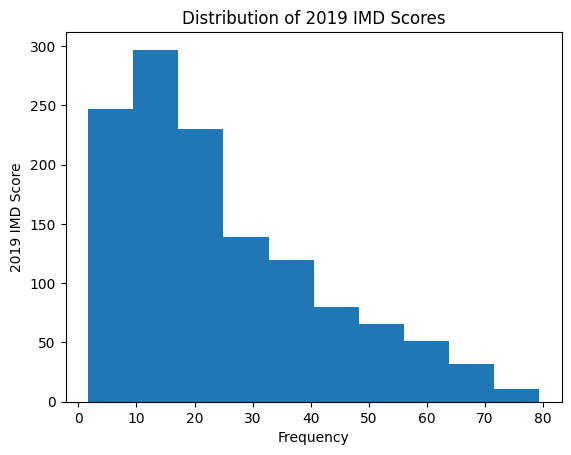

In [303]:
plt.figure()
plt.hist(y_2019, bins=10)
plt.ylabel("2019 IMD Score")
plt.xlabel("Frequency")
plt.title("Distribution of 2019 IMD Scores")
plt.show()

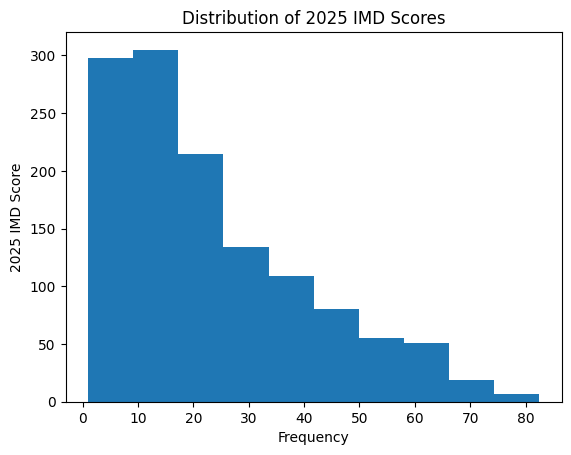

In [304]:
plt.figure()
plt.hist(y_2025, bins=10)
plt.ylabel("2025 IMD Score")
plt.xlabel("Frequency")
plt.title("Distribution of 2025 IMD Scores")
plt.show()

Though as noted, methodology changed between the two reports, scores seem to follow similar scale and distribution. For modeling, the postive skew is removed with a log transformation.

In [305]:
y_log_2019 = np.log1p(y_2019)
y_log_2025 = np.log1p(y_2025)

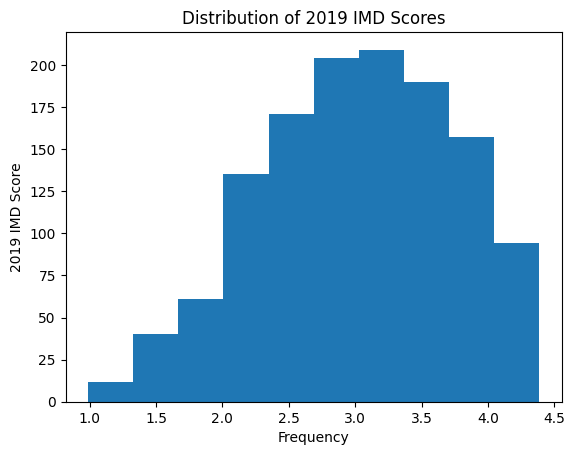

In [306]:
plt.figure()
plt.hist(y_log_2019, bins=10)
plt.ylabel("2019 IMD Score")
plt.xlabel("Frequency")
plt.title("Distribution of 2019 IMD Scores")
plt.show()

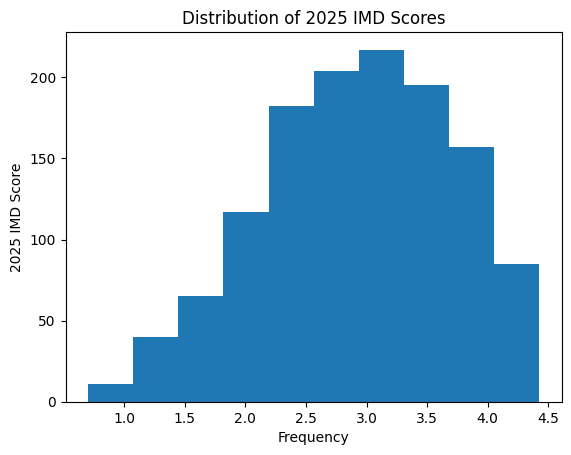

In [307]:
plt.figure()
plt.hist(y_log_2025, bins=10)
plt.ylabel("2025 IMD Score")
plt.xlabel("Frequency")
plt.title("Distribution of 2025 IMD Scores")
plt.show()

Similarity in distribution is now even more striking. To check train and validation splits will have some difference, correlation and scatter of scores is checked.

In [308]:
corr, p_value = spearmanr(y_log_2019, y_log_2025)
print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.9655126102238092
P-value: 0.0


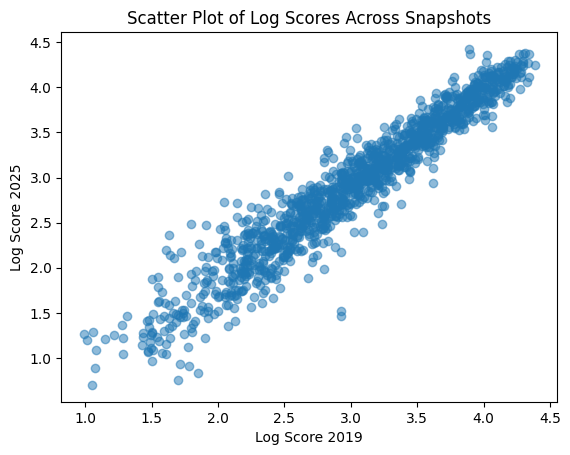

In [309]:
plt.scatter(y_log_2019, y_log_2025, alpha=0.5)
plt.xlabel("Log Score 2019")
plt.ylabel("Log Score 2025")
plt.title("Scatter Plot of Log Scores Across Snapshots")
plt.show()

This is slighlty worrying in that the validation set may not be as unseen as otherwised hoped meaning cv scores should be given more creedence. This is not to say however that feature values are simmilar for the same index since method or score calculation was changed and although there is strong correlation, visually there is still some small difference.

Also, this is to be expected to some extent since intuitively, areas unfortunately seldom improve in deprivation characteristics.

### Feature Correlations

In [310]:
numeric_features_2019 = data_2019.select_dtypes(include=['number'])
numeric_features_2025 = data_2025.select_dtypes(include=['number'])

print(numeric_features_2019.corr().shape, numeric_features_2025.corr().shape) # these should be the same from previous cleaning steps
print("total number of correlations:", numeric_features_2019.size)



(409, 409) (409, 409)
total number of correlations: 520657


Due to large shape visualising as a full heatmap would be innefective. Instead correlation is checked through tables.

In [311]:

corr_with_target_2019 = numeric_features_2019.corr()["imd_score"].abs().sort_values(ascending=False)
corr_with_target_2025 = numeric_features_2025.corr()["imd_score"].abs().sort_values(ascending=False)

corr_with_target_2019 = corr_with_target_2019.drop("imd_score")
corr_with_target_2025 = corr_with_target_2025.drop("imd_score")

print("With target (2019):",end="\n\n")
print(corr_with_target_2019.head(10))
print("\nWith target (2025):",end="\n\n")
print(corr_with_target_2025.head(10))


With target (2019):

total_claims                  0.709513
mean_monthly_claims           0.709513
total_prepfw_claims           0.685240
mean_monthly_prepfw_claims    0.685240
mean_monthly_nwr_claims       0.677565
total_nwr_claims              0.677565
mean_monthly_sfw_claims       0.675686
total_sfw_claims              0.675686
total_planfw_claims           0.635241
mean_monthly_planfw_claims    0.635241
Name: imd_score, dtype: float64

With target (2025):

total_nwr_claims              0.883805
mean_monthly_nwr_claims       0.883805
mean_monthly_claims           0.882561
total_claims                  0.882561
total_prepfw_claims           0.823956
mean_monthly_prepfw_claims    0.823956
total_sfw_claims              0.751780
mean_monthly_sfw_claims       0.751780
total_planfw_claims           0.732128
mean_monthly_planfw_claims    0.732128
Name: imd_score, dtype: float64


Seeing that correlation on UC metrics are strong, a scatterplot is produced. Note that since correlation was taken against the non-log transformed target, the standard target is used for the plot too.

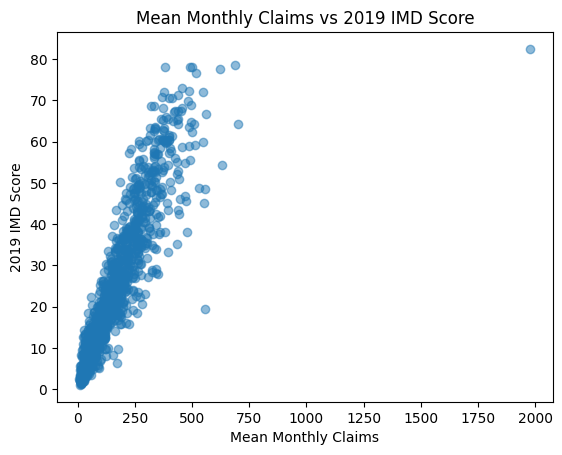

In [312]:
plt.scatter(data_2025[["mean_monthly_claims"]], y_2025, alpha=0.5)
plt.xlabel("Mean Monthly Claims")
plt.ylabel("2019 IMD Score")
plt.title("Mean Monthly Claims vs 2019 IMD Score")
plt.show()

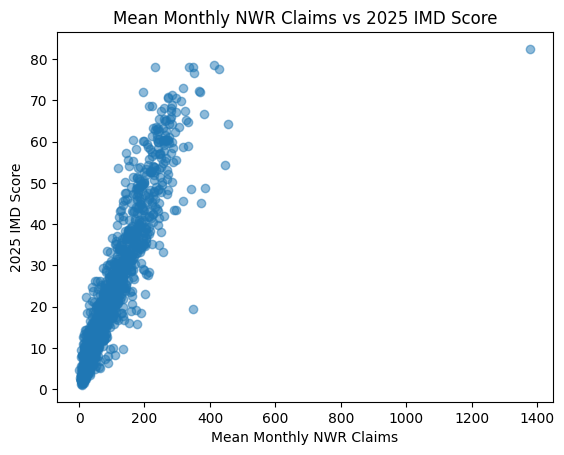

In [313]:
plt.scatter(data_2025[["mean_monthly_nwr_claims"]], y_2025, alpha=0.5)
plt.xlabel("Mean Monthly NWR Claims")
plt.ylabel("2025 IMD Score")  
plt.title("Mean Monthly NWR Claims vs 2025 IMD Score")
plt.show()

Seeing this, it is expected models should perform very well. Possibly to an extent which otherwise would appear to be overfitting. With a dataset of the shape p >> n, it was expected that the feature space would have to be reduced down by PCA, factor analysis or another method. On seeing these high correlations, it may even be sufficient to just select raw features using correlation scores or allow regularisation methods to perform feature extraction. Regardless, both options will be explored. For PCA, correlations between features should be checked.

In [314]:
corr_2019 = numeric_features_2019.corr().abs()
corr_2025 = numeric_features_2025.corr().abs()

def corr_count(corr_matrix, threshold):
    count = corr_matrix[corr_matrix > threshold].count().sum() - len(corr_matrix)  # subtract self-correlations
    return count

count_2019 = corr_count(corr_2019, 0.8)
count_2025 = corr_count(corr_2025, 0.8)

print(f"Number of feature pairs with absolute correlation > 0.8 in 2019: {count_2019}")
print(f"As a percentage of total correlations: {count_2019 / numeric_features_2019.size:.2%}", end="\n\n")

print(f"Number of feature pairs with absolute correlation > 0.8 in 2025: {count_2025}")
print(f"As a percentage of total correlations: {count_2025 / numeric_features_2025.size:.2%}")


Number of feature pairs with absolute correlation > 0.8 in 2019: 5711
As a percentage of total correlations: 1.10%

Number of feature pairs with absolute correlation > 0.8 in 2025: 5098
As a percentage of total correlations: 0.98%


In [315]:
count_2019 = corr_count(corr_2019, 0.5)
count_2025 = corr_count(corr_2025, 0.5)

print(f"Number of feature pairs with absolute correlation > 0.5 in 2019: {count_2019}")
print(f"As a percentage of total correlations: {count_2019 / numeric_features_2019.size:.2%}", end="\n\n")

print(f"Number of feature pairs with absolute correlation > 0.5 in 2025: {count_2025}")
print(f"As a percentage of total correlations: {count_2025 / numeric_features_2025.size:.2%}")

Number of feature pairs with absolute correlation > 0.5 in 2019: 32383
As a percentage of total correlations: 6.22%

Number of feature pairs with absolute correlation > 0.5 in 2025: 31572
As a percentage of total correlations: 6.06%


These measures indicate some multicolinearity. While this may be less of an issue for tree-based models, this could effect regression models. To accomodate for this, PCA seems more relevant because it produces orthogonal features.

### Feature Reduction

As with previous notebooks, feature reduction will be performed using PCA and FA.

## Modelling

On combating overfitting, parameters for hyperparameter tuning are picked specifically with this in mind. As such, the maximum depth on trees, the minimum samples needed for a split and the number of features considered per split are limited whilst the minimum samples per leaf is kept larger. Also, extra trees regressor is used specifically because the dataset has a lot of features and overfitting has been identified.

In [316]:
results = []

reduction_params = {
    'none': [None],
    'pca': [10, 50, 100],
    'fa': [10, 50, 100],
}

# models and param grid
models = {
    'ridge': (
        Ridge(random_state=RANDOM_STATE),
        {'model__alpha': [0.01, 0.1, 1, 10, 100]}
    ),
    'lasso': (
        Lasso(random_state=RANDOM_STATE, max_iter=10000),
        {'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
    ),
    'rf': (
        RandomForestRegressor(random_state=RANDOM_STATE),
        {
            'model__n_estimators': [200, 500],
            'model__max_depth': [5, 10, 15],
            'model__min_samples_split': [5, 10, 20],
            'model__min_samples_leaf': [2, 5, 10],
            'model__max_features': ['sqrt', 0.5],
            'model__bootstrap': [True],
        }
    ),
    'extra_trees': (
        ExtraTreesRegressor(random_state=RANDOM_STATE),
        {
            'model__n_estimators': [200, 500],
            'model__max_depth': [5, 10, 15],
            'model__min_samples_split': [5, 10, 20],
            'model__min_samples_leaf': [2, 5, 10],
            'model__max_features': ['sqrt', 0.5],
        }
    ),
    'gboost': (
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        {
            'model__n_estimators': [200, 500],
            'model__learning_rate': [0.01, 0.05],
            'model__max_depth': [2, 3, 4],
            'model__subsample': [0.6, 0.8, 1.0],
            'model__min_samples_leaf': [1, 5, 10],
        }
    ),
    'xgb': (
        XGBRegressor(random_state=RANDOM_STATE, verbosity=0),
        {
            'model__n_estimators': [200, 500],
            'model__learning_rate': [0.01, 0.05],
            'model__max_depth': [3, 5, 7],
            'model__subsample': [0.6, 0.8],
            'model__colsample_bytree': [0.6, 0.8],
            'model__reg_alpha': [0, 0.1, 1],
            'model__reg_lambda': [1, 5, 10],
            'model__min_child_weight': [1, 5, 10],
        }
    )
}

In [317]:
# Create all combinations upfront
all_configs = list(product(
    reduction_params.items(),
    models.items()
))

total_steps = sum(len(params) for _, params in reduction_params.items()) * len(models)

pbar = tqdm(total=total_steps)

results = []

for reducer_name, components_list in reduction_params.items():
    for n_components in components_list:

        # Define reducer
        if reducer_name == 'pca':
            reducer = PCA(n_components=n_components)
        elif reducer_name == 'fa':
            reducer = FactorAnalysis(n_components=n_components)
        else:
            reducer = 'passthrough'

        for model_name, (model, param_dist) in models.items():

            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('reduce', reducer),
                ('model', model)
            ])

            search = RandomizedSearchCV(
                pipe,
                param_distributions=param_dist,
                n_iter=10,
                scoring='r2',
                cv=5,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )

            search.fit(X_2019, y_log_2019)

            best_model = search.best_estimator_
            best_idx = search.best_index_

            mean_cv_r2 = search.cv_results_['mean_test_score'][best_idx]
            std_cv_r2 = search.cv_results_['std_test_score'][best_idx]

            y_pred = best_model.predict(X_2025)
            val_spearman, _ = spearmanr(y_log_2025, y_pred)
            val_r2 = r2_score(y_log_2025, y_pred)

            results.append({
                'model': model_name,
                'reduction': reducer_name,
                'reduction_param': n_components,
                'mean_cv_r2': mean_cv_r2,
                'std_cv_r2': std_cv_r2,
                'val_spearman': val_spearman,
                'val_r2': val_r2,
                'best_params': search.best_params_
            })

            pbar.update(1)

pbar.close()

results_df = pd.DataFrame(results)

  2%|▏         | 1/42 [02:04<1:24:47, 124.10s/it]
c:\Users\danie\.venvs\ds\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 5 is smaller than n_iter=10. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\danie\.venvs\ds\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


KeyboardInterrupt: 

## Initial Evaluation

In [ ]:
results_df.sort_values(by="mean_cv_r2", ascending=False).head(10)

,model,reduction,reduction_param,mean_cv_r2,std_cv_r2,val_spearman,val_r2,best_params
5,xgb,none,NaN,0.842328,0.067172,0.933079,0.768968,"{'model__subsample': 0.6, 'model__reg_lambda':..."
4,gboost,none,NaN,0.840300,0.069422,0.926646,0.756150,"{'model__subsample': 0.8, 'model__n_estimators..."
2,rf,none,NaN,0.776939,0.134729,0.944585,0.759809,"{'model__n_estimators': 200, 'model__min_sampl..."
34,gboost,fa,50.0,0.757648,0.108087,0.937543,0.820360,"{'model__subsample': 0.8, 'model__n_estimators..."
3,extra_trees,none,NaN,0.757179,0.152995,0.945834,0.742629,"{'model__n_estimators': 200, 'model__min_sampl..."
35,xgb,fa,50.0,0.756331,0.108915,0.934758,0.808725,"{'model__subsample': 0.8, 'model__reg_lambda':..."
41,xgb,fa,100.0,0.726381,0.098963,0.889480,0.690280,"{'model__subsample': 0.6, 'model__reg_lambda':..."
40,gboost,fa,100.0,0.712588,0.128788,0.913286,0.758320,"{'model__subsample': 0.8, 'model__n_estimators..."
32,rf,fa,50.0,0.703999,0.153824,0.942403,0.810274,"{'model__n_estimators': 500, 'model__min_sampl..."
1,lasso,none,NaN,0.668620,0.177073,0.882680,0.719784,{'model__alpha': 0.01}


In [ ]:
results_df.sort_values(by="val_spearman", ascending=False).head(10)

,model,reduction,reduction_param,mean_cv_r2,std_cv_r2,val_spearman,val_r2,best_params
3,extra_trees,none,NaN,0.757179,0.152995,0.945834,0.742629,"{'model__n_estimators': 200, 'model__min_sampl..."
2,rf,none,NaN,0.776939,0.134729,0.944585,0.759809,"{'model__n_estimators': 200, 'model__min_sampl..."
32,rf,fa,50.0,0.703999,0.153824,0.942403,0.810274,"{'model__n_estimators': 500, 'model__min_sampl..."
38,rf,fa,100.0,0.620767,0.237015,0.940972,0.776701,"{'model__n_estimators': 200, 'model__min_sampl..."
33,extra_trees,fa,50.0,0.644977,0.160540,0.938628,0.712060,"{'model__n_estimators': 200, 'model__min_sampl..."
34,gboost,fa,50.0,0.757648,0.108087,0.937543,0.820360,"{'model__subsample': 0.8, 'model__n_estimators..."
39,extra_trees,fa,100.0,0.604058,0.189070,0.937287,0.706629,"{'model__n_estimators': 200, 'model__min_sampl..."
35,xgb,fa,50.0,0.756331,0.108915,0.934758,0.808725,"{'model__subsample': 0.8, 'model__reg_lambda':..."
5,xgb,none,NaN,0.842328,0.067172,0.933079,0.768968,"{'model__subsample': 0.6, 'model__reg_lambda':..."
4,gboost,none,NaN,0.840300,0.069422,0.926646,0.756150,"{'model__subsample': 0.8, 'model__n_estimators..."


Initial impressions of tree based models are promising with both key performance metrics outperforming linear regression models, though I would add that in previous notebooks better cv r squared scores have been observed for L1 and L2 reguarisation methods. It is also important to mention in view of previous issues around overfitting that validation and cv r squared scores are comparable. Specifically, ETR and RF on top performing models by r squared during cv have almost identical r squared values between validation and cv. XGB and GBoost have the highest spearmans r values, but they do have a noticable dip in r squared, indicating some overfitting. This is somewhat expectable since ETR is designed generalises better than gradient boosting models. Though, these have a noticably more unstable r squared during cv.

Feature importance is checked below.

In [ ]:
tree_model_map = {
    'rf': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    'extra_trees': ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    'gboost': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'xgb': XGBRegressor(random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
}

top_models = (
    results_df
    .sort_values('val_spearman', ascending=False)
    .head(3)
)

In [ ]:
all_importances = []
shap_outputs = []


for _, row in top_models.iterrows():

    model_name = row['model']
    reduction_name = row['reduction']
    n_components = row['reduction_param']
    best_params = row['best_params']

    if reduction_name == 'pca':
        reducer = PCA(n_components=n_components, random_state=RANDOM_STATE)
    elif reduction_name == 'fa':
        reducer = FactorAnalysis(n_components=n_components)
    else:
        reducer = 'passthrough'

    model = tree_model_map[model_name]

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('reduce', reducer),
        ('model', model)
    ])

    pipe.set_params(**best_params)
    pipe.fit(X_2019, y_log_2019)

    explainer = shap.TreeExplainer(pipe.named_steps['model'])
    shap_values = explainer.shap_values(X_2019)
    mean_abs_shap = np.abs(shap_values).mean(axis=0)


    r = permutation_importance(
        pipe,
        X_2025,
        y_log_2025,
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    importance = r.importances_mean
    std = r.importances_std

    imp_df = pd.DataFrame({
        'feature': X_2019.columns,
        'importance': importance,
        'shap_importance': mean_abs_shap,
        'std': std,
        'model': model_name,
        'rank': row.name
    })

    all_importances.append(imp_df)

importance_df = pd.concat(all_importances, ignore_index=True)

InvalidParameterError: The 'n_components' parameter of FactorAnalysis must be an int in the range [0, inf) or None. Got 50.0 instead.

In [ ]:
importance_summary = (
    importance_df
    .groupby('feature')
    .agg(
        mean_importance=('importance', 'mean'),
        std_importance=('importance', 'std'),
        mean_shap = ('shap_importance', 'mean')
    )
    .sort_values('mean_importance', ascending=False)
)

importance_summary['stability'] = importance_summary['mean_importance'] / (importance_summary['std_importance'] + 1e-8)


In [ ]:
print('\nTop features (by mean permutation importance):')
print(importance_summary.sort_values(by='mean_importance', ascending=False).head(10))

Top features (by mean permutation importance):
                             mean_importance  std_importance  mean_shap  \
feature                                                                   
mean_monthly_sfw_claims             0.199385        0.011181   0.212741   
total_sfw_claims                    0.168630        0.049153   0.191006   
lsoa_median_price                   0.047772        0.023893   0.069279   
mean_monthly_nwr_claims             0.043985        0.020858   0.130301   
total_nwr_claims                    0.028695        0.010279   0.089955   
mean_monthly_claims                 0.017787        0.017029   0.048284   
total_claims                        0.012935        0.016981   0.029447   
total_transactions                  0.010881        0.002142   0.083788   
working_age_population              0.008578        0.008062   0.106236   
count_waste_sanitation_5000         0.006990        0.001633   0.074903   

                             stability  
feature    

In [ ]:
print('\nTop features (by mean SHAP importance):')
print(importance_summary.sort_values(by='mean_shap', ascending=False).head(10))

Top features (by mean SHAP importance):
                             mean_importance  std_importance  mean_shap  \
feature                                                                   
mean_monthly_sfw_claims         1.993852e-01    1.118109e-02   0.212741   
total_sfw_claims                1.686304e-01    4.915292e-02   0.191006   
mean_monthly_nwr_claims         4.398525e-02    2.085807e-02   0.130301   
working_age_population          8.577688e-03    8.062233e-03   0.106236   
total_nwr_claims                2.869466e-02    1.027926e-02   0.089955   
violent-crime                  -2.590520e-17    4.486913e-17   0.085151   
total_transactions              1.088101e-02    2.141775e-03   0.083788   
count_waste_sanitation_5000     6.990366e-03    1.632706e-03   0.074903   
lsoa_median_price               4.777230e-02    2.389290e-02   0.069279   
mean_monthly_claims             1.778733e-02    1.702913e-02   0.048284   

                                stability  
feature        

In [ ]:

print('\nMost stable features:')
print(importance_summary.sort_values(by='stability', ascending=False).head(10))


Most stable features:
                                                    mean_importance  \
feature                                                               
mean_monthly_sfw_claims                                    0.199385   
count_social_support_1250                                  0.000230   
count_social_support_500                                   0.000228   
ratio_cultural_entertainment_to_fast_food_takea...         0.000078   
D_mean_price                                               0.005006   
total_transactions                                         0.010881   
count_essential_services_500                               0.000115   
count_waste_sanitation_5000                                0.006990   
lsoa_min_price                                             0.001201   
Residential (driving)                                      0.000216   

                                                    std_importance  mean_shap  \
feature                                    

So again, as observed in previous notebooks, UC features seem to be the strongest as well as some of the most stable for prediction. They top both permutation and shapp importance scores. A slight surprise is lsoa median transaction price, this feature stands out as doing well on both these metrics.

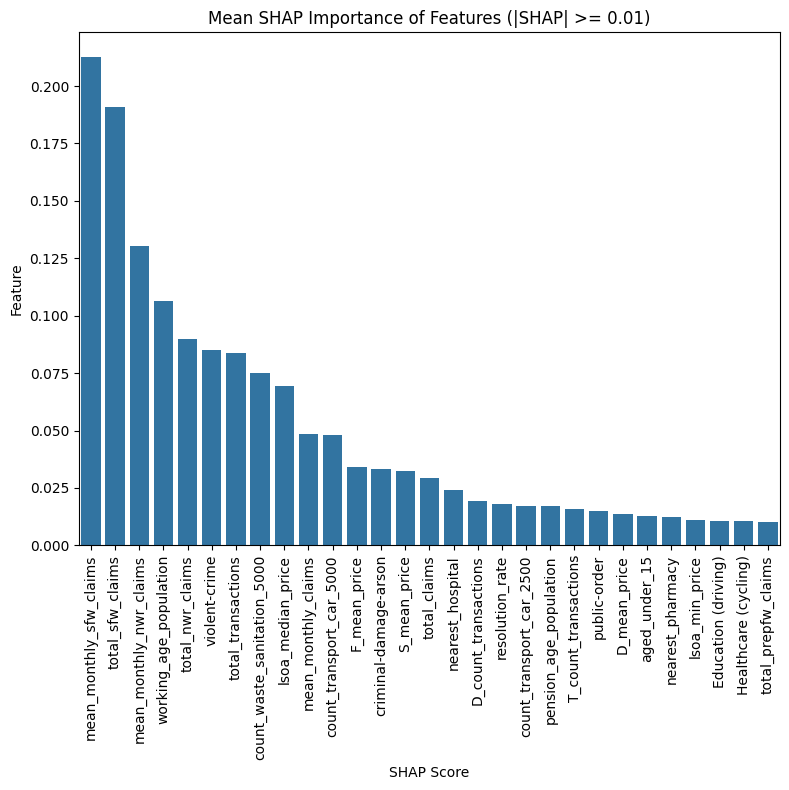

In [ ]:

significant_shap = importance_summary[importance_summary['mean_shap'].abs() >= 0.01].sort_values(by='mean_shap',ascending=False)


plt.figure(figsize=(8, 8))
sns.barplot(
    x='feature', 
    y='mean_shap', 
    data=significant_shap, 
)

plt.title(f'Mean SHAP Importance of Features (|SHAP| >= 0.01)')
plt.xlabel('SHAP Score')
plt.xticks(rotation=90)
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Plotting scores, it can be seen that beyond UC features violent crime, total number of property transactions, the size of the working age population and the number of waste sanitation amenities in a 5km radius are still have relevant importance to the model. This is nice to see since these indicators are not only employment domain related, but actually come from independent sources to each other as well.

## Proposed Best Model 

It is proposed that the best candidate model is the ETR which had the highest spearman correlation metric for the validation set. It performed well on other metrics too and at a glance handles overfitting well. Now with this proposed model, more in depth tuning and cv is performed.

In [ ]:
results_df.sort_values(by='val_spearman', ascending=False).head(1)

,model,reduction,reduction_param,mean_cv_r2,std_cv_r2,val_spearman,val_r2,best_params
3,extra_trees,none,NaN,0.757179,0.152995,0.945834,0.742629,"{'model__n_estimators': 200, 'model__min_sampl..."


In [ ]:
proposed_best_params = results_df.sort_values(by='val_spearman', ascending=False).iloc[0]['best_params']

proposed_best_model = {
    'model': ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    'model_params': proposed_best_params
}

In [ ]:
# etr param grid
etr_grid = {
    'extra_trees': (
        ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {
            'model__n_estimators': [200, 500],
            'model__max_depth': [5, 10, 15],
            'model__min_samples_split': [5, 10, 20],
            'model__min_samples_leaf': [2, 5, 10],
            'model__max_features': ['sqrt', 0.5],
        }
    )
}

In [ ]:
# Spearman scorer (must return scalar only)
def spearman_scorer(y_true, y_pred):
    return spearmanr(y_true, y_pred)[0]

etr_results = []

for model_name, (model, param_dist) in etr_grid.items():

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    search = GridSearchCV(
        pipe,
        param_grid=param_dist,
        scoring={
            'r2': 'r2',
            'spearman': make_scorer(spearman_scorer)
        },
        refit='r2',
        cv=10,
        n_jobs=-1
    )

    search.fit(X_2019, y_log_2019)

    cv = pd.DataFrame(search.cv_results_)

    for i in range(len(cv)):

        params = cv.loc[i, 'params']

        mean_cv_r2 = cv.loc[i, 'mean_test_r2']
        std_cv_r2 = cv.loc[i, 'std_test_r2']

        mean_cv_spearman = cv.loc[i, 'mean_test_spearman']
        std_cv_spearman = cv.loc[i, 'std_test_spearman']

        # fit this config on full training data
        pipe.set_params(**params)
        pipe.fit(X_2019, y_log_2019)

        y_pred = pipe.predict(X_2025)

        val_spearman, _ = spearmanr(y_log_2025, y_pred)
        val_r2 = r2_score(y_log_2025, y_pred)

        etr_results.append({
            'model': model_name,
            'params': params,
            'mean_cv_r2': mean_cv_r2,
            'std_cv_r2': std_cv_r2,
            'mean_cv_spearman': mean_cv_spearman,
            'std_cv_spearman': std_cv_spearman,
            'val_spearman': val_spearman,
            'val_r2': val_r2
        })


etr_results_df = pd.DataFrame(etr_results)

In [ ]:
# add gap feature to help assess if config is overfitting
etr_results_df['val_cv_r2_gap'] =  etr_results_df['val_r2'] - etr_results_df['mean_cv_r2']

etr_results_df.sort_values(by='val_spearman', ascending=False).head()

,model,params,mean_cv_r2,std_cv_r2,mean_cv_spearman,std_cv_spearman,val_spearman,val_r2,val_cv_r2_gap
60,extra_trees,"{'model__max_depth': 10, 'model__max_features'...",0.822750,0.094166,0.921679,0.049283,0.950815,0.761184,-0.061566
62,extra_trees,"{'model__max_depth': 10, 'model__max_features'...",0.822750,0.094166,0.921679,0.049283,0.950815,0.761184,-0.061566
96,extra_trees,"{'model__max_depth': 15, 'model__max_features'...",0.823728,0.096068,0.922431,0.049745,0.950332,0.754171,-0.069556
98,extra_trees,"{'model__max_depth': 15, 'model__max_features'...",0.823728,0.096068,0.922431,0.049745,0.950332,0.754171,-0.069556
97,extra_trees,"{'model__max_depth': 15, 'model__max_features'...",0.824983,0.095003,0.922813,0.049110,0.950033,0.753558,-0.071425


Interestingly spearmans r goes up on best configs between cv and validation, however note that often the gap in r squared is noticeable. To this end, rankings are re-checked with a filter.

In [ ]:
etr_results_df[etr_results_df['val_cv_r2_gap'] > -0.03].sort_values(by='val_spearman', ascending=False).head()

,model,params,mean_cv_r2,std_cv_r2,mean_cv_spearman,std_cv_spearman,val_spearman,val_r2,val_cv_r2_gap
24,extra_trees,"{'model__max_depth': 5, 'model__max_features':...",0.766614,0.110388,0.911113,0.051872,0.947890,0.742229,-0.024385
26,extra_trees,"{'model__max_depth': 5, 'model__max_features':...",0.766614,0.110388,0.911113,0.051872,0.947890,0.742229,-0.024385
28,extra_trees,"{'model__max_depth': 5, 'model__max_features':...",0.765628,0.110326,0.910408,0.051377,0.947242,0.740071,-0.025557
29,extra_trees,"{'model__max_depth': 5, 'model__max_features':...",0.769939,0.106773,0.911628,0.050681,0.946819,0.741046,-0.028893
33,extra_trees,"{'model__max_depth': 5, 'model__max_features':...",0.767484,0.110063,0.910614,0.051624,0.946495,0.741887,-0.025596


In [ ]:
etr_results_df[etr_results_df['val_cv_r2_gap'] > -0.03].sort_values(by='mean_cv_r2', ascending=False).head()

,model,params,mean_cv_r2,std_cv_r2,mean_cv_spearman,std_cv_spearman,val_spearman,val_r2,val_cv_r2_gap
29,extra_trees,"{'model__max_depth': 5, 'model__max_features':...",0.769939,0.106773,0.911628,0.050681,0.946819,0.741046,-0.028893
33,extra_trees,"{'model__max_depth': 5, 'model__max_features':...",0.767484,0.110063,0.910614,0.051624,0.946495,0.741887,-0.025596
31,extra_trees,"{'model__max_depth': 5, 'model__max_features':...",0.767484,0.110063,0.910614,0.051624,0.946495,0.741887,-0.025596
35,extra_trees,"{'model__max_depth': 5, 'model__max_features':...",0.767484,0.110063,0.910614,0.051624,0.946495,0.741887,-0.025596
24,extra_trees,"{'model__max_depth': 5, 'model__max_features':...",0.766614,0.110388,0.911113,0.051872,0.947890,0.742229,-0.024385


Here model at index 29 seems highly promising. It has a relatively high r squared during cv and the gap is not too large. Also, spearmans r scores on cv and validation are equally high with small spread. Standard deviation on r squared scores during cv seem a bit high so these are checked below to see if better scores are available.

In [ ]:
etr_results_df[etr_results_df['val_cv_r2_gap'] > -0.03]['std_cv_r2'].describe()

count    64.000000
mean      0.104177
std       0.008023
min       0.090420
25%       0.097367
50%       0.101342
75%       0.110583
max       0.117829
Name: std_cv_r2, dtype: float64

After checking r squared standard deviation spread, it can be seen that few models perform better.

In [ ]:
best_etr_params = etr_results_df[etr_results_df['val_cv_r2_gap'] > -0.03].sort_values(by='mean_cv_r2', ascending=False).iloc[0]['params']

In [ ]:
best_etr_params

{'model__max_depth': 5,
 'model__max_features': 0.5,
 'model__min_samples_leaf': 5,
 'model__min_samples_split': 20,
 'model__n_estimators': 500}

In [ ]:
proposed_best_params

{'model__n_estimators': 200,
 'model__min_samples_split': 20,
 'model__min_samples_leaf': 2,
 'model__max_features': 0.5,
 'model__max_depth': 10}

Observe the difference in best selected parameters with more depth given to looking into ETR specifically. A model with more estimators but shallower trees is selected, possibly because the first was not picked up during RandomGridSearch or perhaps it was filtered out by introducing an explicit validation-cv gap feature for filtering. Regardless, the parameters found should be recorded and I believe can be sued as a candidate for the final model on nowcasting.

Before concluding however, feature importance is re-checked using SHAP analysis.

In [ ]:
pipe = Pipeline([
    ('model', ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

pipe.set_params(**best_etr_params)
pipe.fit(X_2019, y_log_2019)

explainer = shap.TreeExplainer(pipe.named_steps['model'])
shap_values = explainer.shap_values(X_2019)
mean_abs_shap = np.abs(shap_values).mean(axis=0)

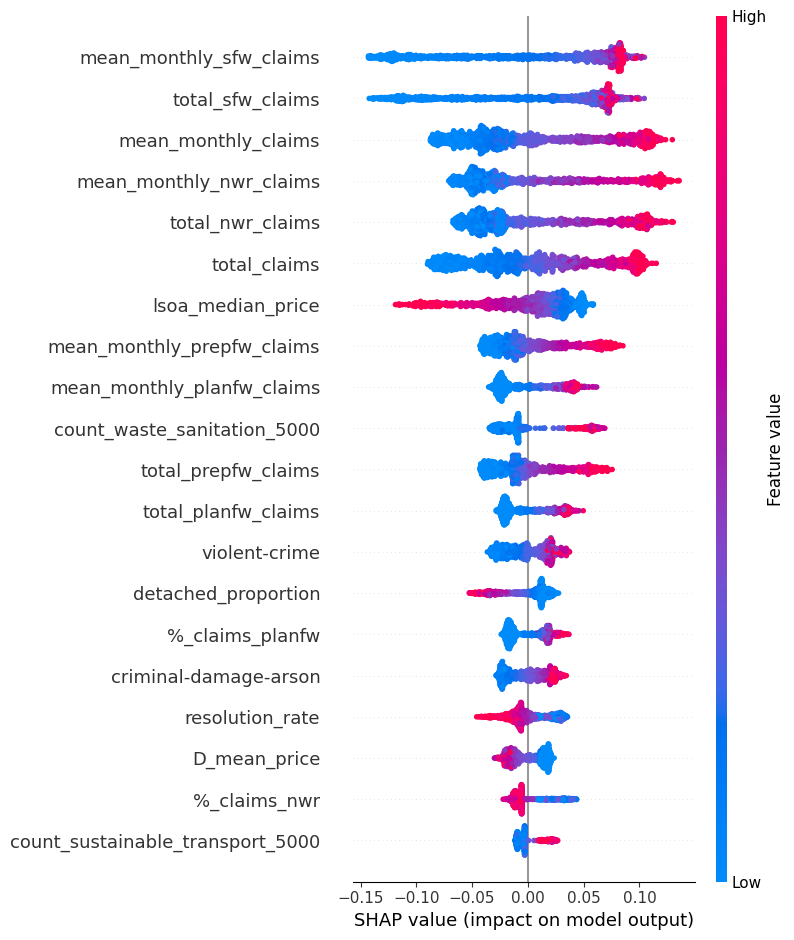

In [ ]:
shap.summary_plot(
    shap_values,
    X_2019,
    feature_names=X_2019.columns,
)

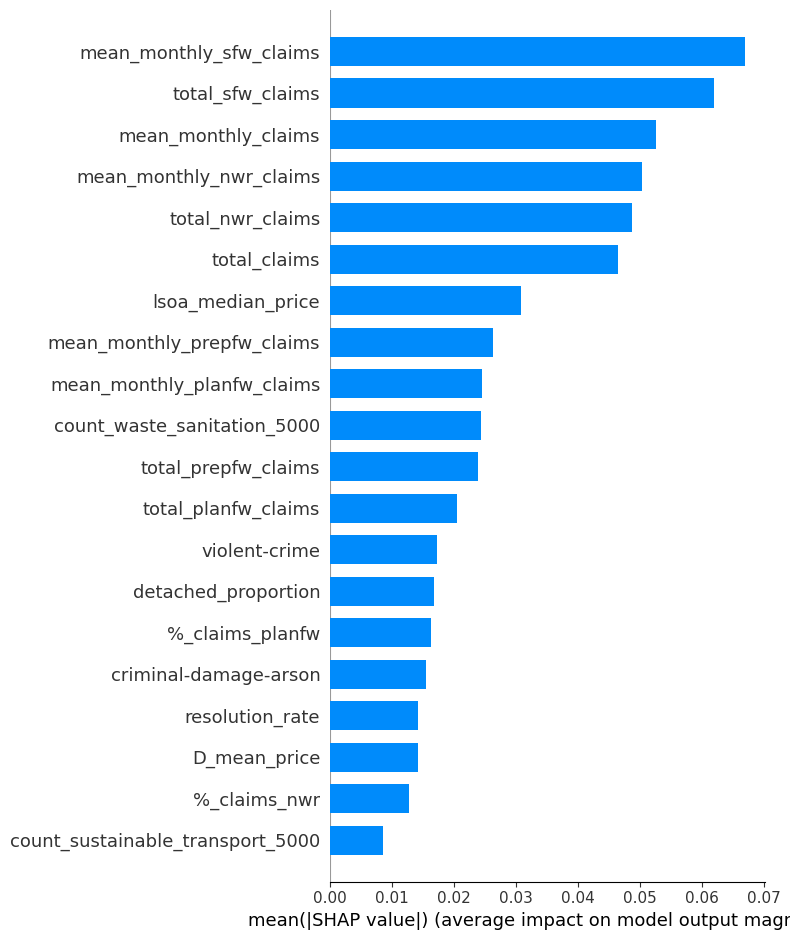

In [ ]:
shap.summary_plot(
    shap_values,
    X_2019,
    feature_names=X_2019.columns,
    plot_type="bar"
)

Perhaps redundant to say at this stage in the analysis, but yet again, UC related features come out as the most impactful. Outside of this, features identified as important previously are again significant. It is also worth noting that median transaction price is the only feature identified as having strong negative impact on an LSOA being deprived.

### Summary

The notebook succesfully demonstrates the predictive power of tree based methods. Their model metrics are strong enough to suggest that any of the four model types explored could be used, though the two boosting models have a slight edge in r squared during cross validation with a noted overfitting gap. It should also be noted, that parameters were selected from hyperparameter tuning with previously known issues of overfitting in mind. As such, the metrics obtained should be more trustworthy than otherwise.

Feature importance also backs up what has been previously known about the predictive strength of UC features.

With the extra depth given to ETR after observing a model of that type to perform particurlalry well, hyperparameter tuning was used to identify a specific model with promising metrics. Here gap between validation and cv is acceptable and all other performance indicators are high. An ETR with those parameters is selected as a strong candidate to be the final model used for nowcasting.

SHAP analysis performed on this final model shows that outside of UC, it seems at least one feature shows up from each source used for fetching. 

But beyond feature analysis, the key takeaway from this notebook should be the selection of an ETR with tuned and selected parameters as a viable model for nowcasting with metrics to back up its efficacy.